In [25]:
!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 13.95M 100 13.95M   0      0 79.01M      0                              0
100 13.95M 100 13.95M   0      0 78.95M      0                              0
100 13.95M 100 13.95M   0      0 78.87M      0                              0


In [26]:
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt 

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  4.66M 100  4.66M   0      0 33.64M      0                              0
100  4.66M 100  4.66M   0      0 33.61M      0                              0
100  4.66M 100  4.66M   0      0 33.59M      0                              0


In [27]:
import pandas as pd

ratings_train_df = pd.read_csv('ratings_train.txt', sep='\t')
ratings_test_df = pd.read_csv('ratings_test.txt', sep='\t')

ratings_train_df.shape, ratings_test_df.shape

((150000, 3), (50000, 3))

In [28]:
ratings_train_df = ratings_train_df.dropna(how='any')
ratings_test_df = ratings_test_df.dropna(how='any')


ratings_train_df.isnull().sum(), ratings_test_df.isnull().sum()
ratings_train_df.shape, ratings_test_df.shape

((149995, 3), (49997, 3))

In [29]:
ratings_train_df = ratings_train_df.sample(n=50000, random_state=42)
ratings_test_df = ratings_test_df.sample(n=5000, random_state=42)

ratings_train_df.shape, ratings_test_df.shape

((50000, 3), (5000, 3))

In [30]:
import re
from konlpy.tag import Okt

def load_stopwords(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        stopwords = [line.strip() for line in f]
    return stopwords

def preprocessing(sentence, okt=Okt()):
    sentence = re.sub(r'\n', ' ', sentence)
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', sentence)

    tokens = okt.morphs(sentence, stem=True)

    ko_stopwords = load_stopwords('ko_stopwords.txt')

    tokens = [token for token in tokens if token not in ko_stopwords]

    return tokens

In [31]:
sample = '''
    이런 영화 진짜 fantastic.
    너무 못 만들었다.
    그런데 감동이다
'''

preprocessing(sample)

['이렇다', '영화', '진짜', '너무', '못', '만들다', '감동', '이다']

In [32]:
from tqdm import tqdm

X_train, y_train, X_test, y_test = [], [], [], []

for index, row in tqdm(ratings_train_df.iterrows()):
    doc, label = row['document'], row['label']
    X_train.append(preprocessing(doc))
    y_train.append(label)

for index, row in tqdm(ratings_test_df.iterrows()):
    doc, label = row['document'], row['label']
    X_test.append(preprocessing(doc))
    y_test.append(label)

print(len(X_train), len(y_train), len(X_test), len(y_test))

0it [00:00, ?it/s]

50000it [02:47, 298.62it/s]
5000it [00:16, 308.66it/s]

50000 50000 5000 5000


In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOv>')
tokenizer.fit_on_texts(X_train)

X_train_encoded = tokenizer.texts_to_sequences(X_train)
X_test_encoded = tokenizer.texts_to_sequences(X_test)

print(X_train_encoded[:3])
print(X_test_encoded[:3])

[[8735, 28], [471, 295, 794, 2], [648, 409, 16, 2, 55, 126, 32, 209]]
[[1066, 240, 4, 138, 28, 1473], [227, 9], [1540, 8, 262]]


61


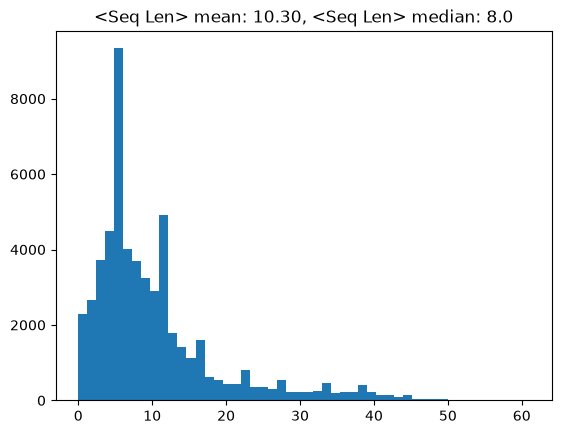

In [34]:
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq) for seq in X_train_encoded]
X_test_len = [len(seq) for seq in X_test_encoded]

mean = np.mean(X_train_len + X_test_len)
median = np.median(X_train_len + X_test_len)
print(max(X_train_len))

plt.hist(X_train_len + X_test_len, bins=50)
plt.title(f'<Seq Len> mean: {mean:.2f}, <Seq Len> median: {median}')
plt.show()

In [35]:
max_len = 15

X_train_padded = pad_sequences(X_train_encoded, maxlen=max_len)
X_test_padded = pad_sequences(X_test_encoded, maxlen=max_len)

In [39]:
def decode_sentence(encoded_sentence):
    decoded = [tokenizer.index_word.get(n, '_') for n in encoded_sentence]
    return ' '.join(decoded)

print(X_train_padded[0])
print(decode_sentence(X_train_padded[0]))

print(ratings_test_df.iloc[0, 1])
print(X_test_padded[0])
print(decode_sentence(X_test_padded[0]))

print(X_train_padded.shape, X_test_padded.shape)
print(len(y_train), len(y_test))

[   0    0    0    0    0    0    0    0    0    0    0    0    0 8735
   28]
_ _ _ _ _ _ _ _ _ _ _ _ _ 원본 최고
찐한 여운과 함께...내 인생 최고의 미드
[   0    0    0    0    0    0    0    0    0 1066  240    4  138   28
 1473]
_ _ _ _ _ _ _ _ _ 찌다 여운 하다 인생 최고 미드
(50000, 15) (5000, 15)
50000 5000


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

class BiLSTMSentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)

        forward_pass = hidden[-2]
        backward_pass = hidden[-1]
        hidden_merged = torch.cat((forward_pass, backward_pass), dim=1)

        output = self.fc(hidden_merged)
        return output

model = BiLSTMSentimentNet(vocab_size, embedding_dim=100, hidden_dim=128)
model

BiLSTMSentimentNet(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

In [41]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
BiLSTMSentimentNet                       --
├─Embedding: 1-1                         2,000,000
├─LSTM: 1-2                              235,520
├─Linear: 1-3                            257
Total params: 2,235,777
Trainable params: 2,235,777
Non-trainable params: 0

In [42]:
from torch.utils.data import random_split, DataLoader, TensorDataset

X_train_padded = torch.tensor(X_train_padded, dtype=torch.long)
X_test_padded = torch.tensor(X_test_padded, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)

print(X_train_padded.shape, X_test_padded.shape)
print(y_train.shape, y_test.shape)

torch.Size([50000, 15]) torch.Size([5000, 15])
torch.Size([50000, 1]) torch.Size([5000, 1])


In [43]:
batch_size = 64
train_size = int(len(X_train_padded) * 0.8)
val_size = len(X_train_padded) - train_size

train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)
test_dataset = TensorDataset(X_test_padded, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))
print(len(train_dataloader), len(val_dataloader), len(test_dataloader))

40000 10000 5000
625 157 79


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

torch.cuda.empty_cache()

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

epochs = 100

trian_losses, val_losses, train_accs, val_accs = [], [], [], []

early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

device: cpu


In [45]:
from tqdm.auto import tqdm

for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    model.train()
    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_dataloader)
    trian_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device).float()

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]

    print(f'Epoch {epoch+1}/{epochs}\n',
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}',
          f'Valid Loss: {val_loss:.4f}, Valid Acc: {val_acc:.4f}',
          f'lr: {lr}'
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f'Early Stopping on{epoch+1} Epoch')
            break

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100
 Train Loss: 0.6341, Train Acc: 0.6460 Valid Loss: 0.5778, Valid Acc: 0.6974 lr: 0.0001
Epoch 2/100
 Train Loss: 0.5215, Train Acc: 0.7346 Valid Loss: 0.4946, Valid Acc: 0.7484 lr: 0.0001
Epoch 3/100
 Train Loss: 0.4467, Train Acc: 0.7836 Valid Loss: 0.4643, Valid Acc: 0.7773 lr: 0.0001
Epoch 4/100
 Train Loss: 0.4076, Train Acc: 0.8107 Valid Loss: 0.4502, Valid Acc: 0.7841 lr: 0.0001
Epoch 5/100
 Train Loss: 0.3795, Train Acc: 0.8270 Valid Loss: 0.4451, Valid Acc: 0.7895 lr: 0.0001
Epoch 6/100
 Train Loss: 0.3568, Train Acc: 0.8414 Valid Loss: 0.4344, Valid Acc: 0.7968 lr: 0.0001
Epoch 7/100
 Train Loss: 0.3369, Train Acc: 0.8524 Valid Loss: 0.4469, Valid Acc: 0.7898 lr: 0.0001
Epoch 8/100
 Train Loss: 0.3172, Train Acc: 0.8647 Valid Loss: 0.4403, Valid Acc: 0.8002 lr: 0.0001
Epoch 9/100
 Train Loss: 0.2996, Train Acc: 0.8745 Valid Loss: 0.4449, Valid Acc: 0.7981 lr: 0.0001
Epoch 10/100
 Train Loss: 0.2821, Train Acc: 0.8832 Valid Loss: 0.4499, Valid Acc: 0.8021 lr: 5e-05


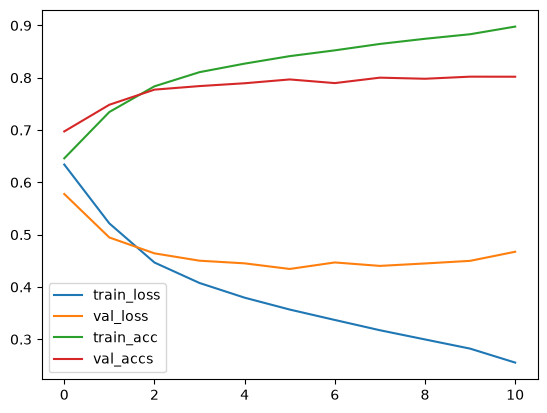

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss': trian_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_accs': val_accs
})

df.plot()
plt.show()

In [47]:
def evaluate_model(model, test_dataloader, criterion, device):
    model.to(device).eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for test_inputs, test_labels in test_dataloader:
            test_inputs = test_inputs.to(device)
            test_labels = test_labels.to(device).float()

            output = model(test_inputs)
            loss = criterion(output, test_labels)

            test_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            test_correct += (pred == test_labels).sum().item()
            test_total += test_labels.size(0)

        test_loss = test_loss / len(test_dataloader)
        test_acc = test_correct / test_total
    return test_loss, test_acc

test_dataset = TensorDataset(X_test_padded, y_test)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)

test_loss, test_acc = evaluate_model(model, test_dataloader, criterion, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

Test Loss: 0.4914, Test Acc: 0.7960


In [53]:
def movie_review_sentimental_analysis(sentences):
    tokens = [preprocessing(sent) for sent in sentences]
    encoded_sequences = tokenizer.texts_to_sequences(tokens)
    padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len)

    X = torch.tensor(padded_sequences, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(X)
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()

        return ['긍정' if pr == 1 else '부정' for pr in pred]

samples = [
    '이 영화는 못봐주겠네',
    '너무 구리다',
    '오랜만에 감동을 느꼈다~',
    '감독이 생각이 있나?',
    '내가 만들어도 이거보다 나을거같은데?',
    '하츄핑보다 재미없는데?',
    '역시 봉준호야',
    '개구리다',
    '강아지'
]

movie_review_sentimental_analysis(samples)

['부정', '부정', '긍정', '부정', '부정', '부정', '긍정', '부정', '부정']